In [28]:
import random
import matplotlib.pyplot as plt
import pandas


In [29]:
class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None
        self.depth = 0
        self.comparisons = 0

    def insert(self, key):
        if not self.root:
            self.root = Node(key)
        else:
            self.insert_helper(self.root, key, 0)

    def insert_helper(self, node, key, depth):
        if not node:
            self.depth = max(self.depth, depth)
            return Node(key)
        else:
            self.comparisons += 1
            if key < node.key:
                node.left = self.insert_helper(node.left, key, depth + 1)
            else:
                node.right = self.insert_helper(node.right, key, depth + 1)
            return node    

In [ ]:
# Random Insertion from 1 - n 
results = {}
rows = []
for n in random.sample(range(1, 100001), 100):
    # Several Times per each n?
    for i in range(8):
        bst = BST()
        for key in random.sample(range(1, n + 1), n):
            bst.insert(key)
        rows.append({"n": n, "depth": bst.depth, "comparisons": bst.comparisons})

df = pandas.DataFrame(rows)

# clean values 
n = df['n']
depth = df['depth']
comparisons = df['comparisons']


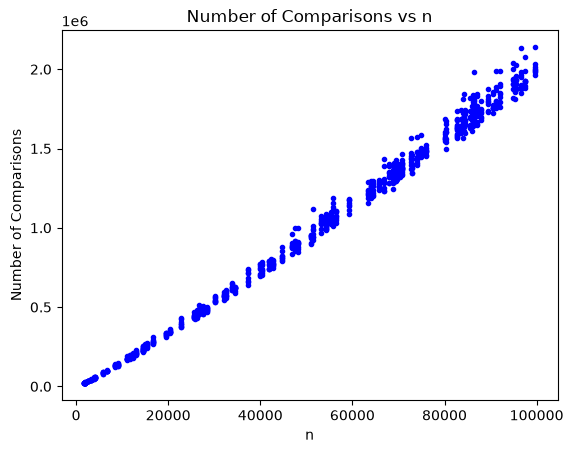

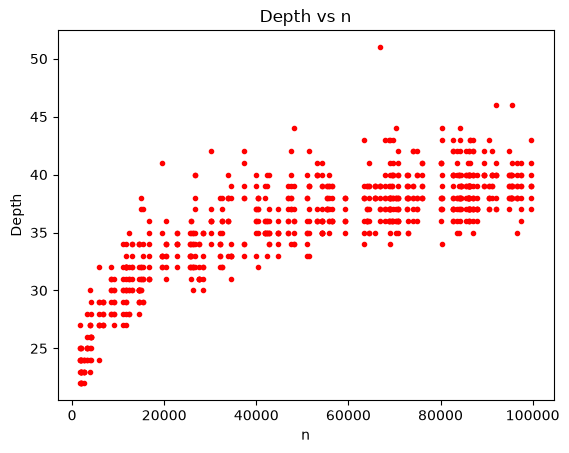

In [ ]:
# Graph out the results of the random insertions.  
comp_fig, comp_ax = plt.subplots()
depth_fig, depth_ax = plt.subplots()

# Titles
comp_ax.set_title('Number of Comparisons vs n')
depth_ax.set_title('Depth vs n')
comp_ax.set_xlabel('n')
comp_ax.set_ylabel('Number of Comparisons')
depth_ax.set_xlabel('n')
depth_ax.set_ylabel('Depth')


# plot values
comp_ax.plot(n, comparisons, marker='o', linestyle='none', color='blue',markersize=3)
depth_ax.plot(n, depth, marker='o', linestyle='none', color='red',markersize=3)

plt.show()